In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

GOLD_PATH = Path("../data/gold")
OUTPUT_PATH = Path("../data/analysis")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Goldlayer laden
dim_product = pd.read_parquet(GOLD_PATH/"dim_product.parquet")
dim_customer = pd.read_parquet(GOLD_PATH/"dim_customer.parquet")
dim_date = pd.read_parquet(GOLD_PATH/"dim_date.parquet")
fact_sales = pd.read_parquet(GOLD_PATH/"fact_sales.parquet")

print("dim_product:", dim_product.shape)
print("dim_customer:", dim_customer.shape)
print("dim_date:", dim_date.shape)
print("fact_sales:", fact_sales.shape)

dim_product: (3665, 3)
dim_customer: (4338, 3)
dim_date: (374, 11)
fact_sales: (397884, 7)


In [4]:
# View bauen
sales_analysis = (
    fact_sales
    .merge(dim_product, on="ProductKey", how="left")
    .merge(dim_customer, on="CustomerKey", how="left")
    .merge(dim_date, on="DateKey", how="left")
)

print(sales_analysis.shape)
sales_analysis.head()

(397884, 21)


,InvoiceNo,DateKey,ProductKey,CustomerKey,Quantity,UnitPrice,Revenue,StockCode,Description,CustomerID,Country,Date,Year,Quarter,MonthNumber,MonthName,YearMonth,Day,Weekday,WeekdayNumber,IsWeekend
0,536365,20101201,3234,4017,6,2.55,15.30,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17850,United Kingdom,2010-12-01,2010,4,12,December,2010-12,1,Wednesday,2,False
1,536365,20101201,2644,4017,6,3.39,20.34,71053,WHITE METAL LANTERN,17850,United Kingdom,2010-12-01,2010,4,12,December,2010-12,1,Wednesday,2,False
2,536365,20101201,2848,4017,8,2.75,22.00,84406B,CREAM CUPID HEARTS COAT HANGER,17850,United Kingdom,2010-12-01,2010,4,12,December,2010-12,1,Wednesday,2,False
3,536365,20101201,2796,4017,6,3.39,20.34,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,17850,United Kingdom,2010-12-01,2010,4,12,December,2010-12,1,Wednesday,2,False
4,536365,20101201,2795,4017,6,3.39,20.34,84029E,RED WOOLLY HOTTIE WHITE HEART.,17850,United Kingdom,2010-12-01,2010,4,12,December,2010-12,1,Wednesday,2,False


In [5]:
# Qualitychecks
assert sales_analysis["ProductKey"].isna().sum() == 0
assert sales_analysis["CustomerKey"].isna().sum() == 0
assert sales_analysis["DateKey"].isna().sum() == 0

assert sales_analysis["Revenue"].min() > 0
assert sales_analysis["Quantity"].min() > 0
assert sales_analysis["UnitPrice"].min() > 0 

In [6]:
# KPIs im Dictionary
kpi_df = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Units Sold",
        "Total Customers",
        "Total Products",
        "Average ORder Value"
    ],
    "Value":[
        sales_analysis["Revenue"].sum(),
        sales_analysis["InvoiceNo"].nunique(),
        sales_analysis["Quantity"].sum(),
        sales_analysis["CustomerID"].nunique(),
        sales_analysis["StockCode"].nunique(),
        sales_analysis.groupby("InvoiceNo")["Revenue"].sum().mean()
    ]
})

print(kpi_df)

                   KPI        Value
0        Total Revenue 8,911,407.90
1         Total Orders    18,532.00
2     Total Units Sold 5,167,812.00
3      Total Customers     4,338.00
4       Total Products     3,665.00
5  Average ORder Value       480.87


In [7]:
# Monatssicht
monthly_sales_summary = (
    sales_analysis
    .groupby(["Year", "MonthNumber", "MonthName", "YearMonth"], as_index=False)
    .agg(
        Revenue = ("Revenue", "sum"),
        Orders = ("InvoiceNo", "nunique"),
        Units = ("Quantity", "sum"),
        Customers = ("CustomerID", "nunique")
    )
    .sort_values(["Year", "MonthNumber"])
)

monthly_sales_summary.head()

,Year,MonthNumber,MonthName,YearMonth,Revenue,Orders,Units,Customers
0,2010,12,December,2010-12,"572,713.89",1400,312265,885
1,2011,1,January,2011-01,"569,445.04",987,349098,741
2,2011,2,February,2011-02,"447,137.35",997,265622,758
3,2011,3,March,2011-03,"595,500.76",1321,348503,974
4,2011,4,April,2011-04,"469,200.36",1149,292222,856


In [8]:
# Ländersicht
country_sales_summary = (
    sales_analysis
    .groupby("Country", as_index=False)
    .agg(
        Revenue = ("Revenue", "sum"),
        Orders = ("InvoiceNo", "nunique"),
        Units = ("Quantity", "sum"),
        Customers = ("CustomerID", "nunique")
    )
    .sort_values("Revenue", ascending = False)
)
country_sales_summary.head()

,Country,Revenue,Orders,Units,Customers
35,United Kingdom,"7,308,391.55",16646,4256740,3920
23,Netherlands,"285,446.34",94,200361,9
10,EIRE,"265,545.90",260,140275,3
14,Germany,"228,867.14",457,119261,94
13,France,"209,024.05",389,111471,87


In [34]:
# Produktsicht
product_sales_summary = (
    sales_analysis
    .groupby(["ProductKey", "StockCode", "Description"], as_index = False)
    .agg(
        Revenue = ("Revenue", "sum"),
        Units = ("Quantity", "sum"),
        Orders = ("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending = False)
)

product_sales_summary.head()

,ProductKey,StockCode,Description,Revenue,Units,Orders
2399,2400,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
1288,1289,22423,REGENCY CAKESTAND 3 TIER,"142,592.95",12402,1703
3233,3234,85123A,CREAM HANGING HEART T-LIGHT HOLDER,"100,603.50",36782,1978
3219,3220,85099B,JUMBO BAG RED RETROSPOT,"85,220.78",46181,1600
1997,1998,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195


In [39]:
# Ordersicht
order_summary = (
    sales_analysis
    .groupby(["InvoiceNo"], as_index = False)
    .agg(
        OrderRevenue = ("Revenue", "sum"),
        OrderUnits = ("Quantity", "sum"),
        DistinctProducts = ("StockCode", "nunique"),
        CustomerID = ("CustomerID", "first"),
        Country = ("Country", "first"),
        Date = ("Date", "first")
    )
)

# order_summary.head()

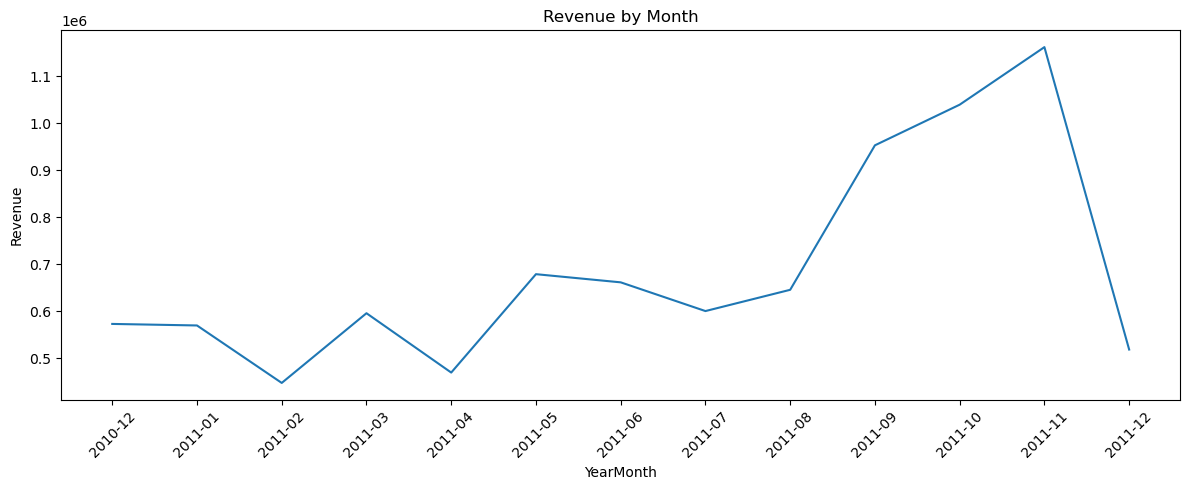

In [30]:
# Plot
plt.figure(figsize = (12,5))
plt.plot(monthly_sales_summary["YearMonth"], monthly_sales_summary["Revenue"])
plt.xticks(rotation=45)
plt.title("Revenue by Month")
plt.xlabel("YearMonth")
plt.ylabel("Revenue")
plt.tight_layout()

plt.show()

In [41]:
# Speichern
sales_analysis.to_parquet(OUTPUT_PATH/"sales_analysis.parquet", engine = "pyarrow")
monthly_sales_summary.to_parquet(OUTPUT_PATH / "monthly_sales_summary.parquet", engine="pyarrow")
country_sales_summary.to_parquet(OUTPUT_PATH / "country_sales_summary.parquet", engine="pyarrow")
product_sales_summary.to_parquet(OUTPUT_PATH / "product_sales_summary.parquet", engine="pyarrow")
order_summary.to_parquet(OUTPUT_PATH / "order_summary.parquet", engine="pyarrow")